In [106]:
import sys

import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np
import torch
import torch.nn as nn

from src.utils import extract_ds_values, load_losses, ns_residuals, plot_field

sys.setrecursionlimit(10000)

In [107]:
H5_FILE_T = "../coarse_dataset/AllFields_Resultats_MESH_210.h5"
T = 8

RE = 520
nu = 1 / RE

Q = 7

P  = -3700 + 1.32 * Q

x, y, uv = extract_ds_values(H5_FILE_T, T)

inside_points = torch.tensor(
    np.column_stack((x / 20, y / 14)),
).double().requires_grad_(True)
inside_labels = torch.tensor(uv / 1000).double()

model = nn.Sequential(
    nn.Linear(2, 256),
    nn.Tanh(),
    nn.Linear(256, 256),
    nn.Tanh(),
    nn.Linear(256, 256),
    nn.Tanh(),
    nn.Linear(256, 3)
).double()

model.load_state_dict(torch.load("../models/spee_ft/model_02/DS_Model_03.pt"))

inside_results_after = model(inside_points)

model.load_state_dict(torch.load("../models/model_30/AN_model_01.pt"))

inside_results_before = model(inside_points)

model.eval()

RuntimeError: Error(s) in loading state_dict for Sequential:
	Unexpected key(s) in state_dict: "8.weight", "8.bias". 
	size mismatch for 0.weight: copying a param with shape torch.Size([128, 2]) from checkpoint, the shape in current model is torch.Size([256, 2]).
	size mismatch for 0.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for 2.weight: copying a param with shape torch.Size([128, 128]) from checkpoint, the shape in current model is torch.Size([256, 256]).
	size mismatch for 2.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for 4.weight: copying a param with shape torch.Size([128, 128]) from checkpoint, the shape in current model is torch.Size([256, 256]).
	size mismatch for 4.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for 6.w

In [ ]:
inside_results = model(inside_points)

x = inside_points.detach().numpy()[:, 0]
y = inside_points.detach().numpy()[:, 1]

v_a = inside_results_after.detach().numpy()[:, 1]
v_b = inside_results_before.detach().numpy()[:, 1]

u_l = inside_labels.detach().numpy()[:, 0]
v_l = inside_labels.detach().numpy()[:, 1]

plot_field(x, y, v_a, "v prédiction", "m/s", False)

In [ ]:
plot_field(x, y, np.abs(v_l - v_a), "Erreur absolue", "sans unité", False)

In [ ]:
import matplotlib.colors as mcolors

def plot_fields_comparison(x, y, z1, z2, title1, title2, z_label, show_norm=False):
    vmin = min(z1.min(), z2.min())
    vmax = max(z1.max(), z2.max())

    def make_triang(x, y):
        triang = tri.Triangulation(x, y)
        triangles = triang.triangles
        x_tri = x[triangles]
        y_tri = y[triangles]
        a = np.sqrt((x_tri[:, 1] - x_tri[:, 0])**2 + (y_tri[:, 1] - y_tri[:, 0])**2)
        b = np.sqrt((x_tri[:, 2] - x_tri[:, 1])**2 + (y_tri[:, 2] - y_tri[:, 1])**2)
        c = np.sqrt((x_tri[:, 0] - x_tri[:, 2])**2 + (y_tri[:, 0] - y_tri[:, 2])**2)
        triang.set_mask(np.max(np.stack([a, b, c], axis=1), axis=1) > 0.05)
        return triang

    triang = make_triang(x, y)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, z, title in zip(axes, [z1, z2], [title1, title2]):
        if show_norm:
            norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
            tcf = ax.tripcolor(triang, z, cmap='RdBu_r', shading='gouraud', norm=norm)
        else:
            tcf = ax.tripcolor(triang, z, cmap='viridis', shading='gouraud',
                               vmin=vmin, vmax=vmax)
        ax.set_aspect('auto')
        ax.set_xlim(x.min() - 0.05, x.max() + 0.05)
        ax.set_ylim(y.min() - 0.05, y.max() + 0.05)
        ax.set_title(f"{title}\nmax={z.max():.4f}  moy={z.mean():.4f}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        fig.colorbar(tcf, ax=ax, label=z_label)

    plt.tight_layout()
    plt.show()


# Appel
plot_fields_comparison(
    x, y,
    np.abs(v_l - v_b), np.abs(v_l - v_a),
    "Erreur absolue — avant transfert",
    "Erreur absolue — après transfert",
    z_label="sans unité",
)

In [ ]:
ns = ns_residuals(inside_points, inside_results[:, 0], inside_results[:, 1], inside_results[:, 2], nu)

ns_x = ns[0].detach().numpy()
ns_y = ns[1].detach().numpy()
cont = ns[2].detach().numpy()

In [ ]:
plot_field(x, y, ns_y + ns_x, "Résidus Conservation", "sans unités")
print((ns_y + ns_x).max())

In [7]:
import json
import numpy as np

losses = []

with open("../models/spee_ft/model_01/DS_Model_03.json", "r") as f:
    losses = [i for i in json.load(f)]

losses = np.array(losses)

/var/folders/sq/58r9s_pj3wn5m42htsn9jh800000gn/T/ipykernel_95596/2461136811.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


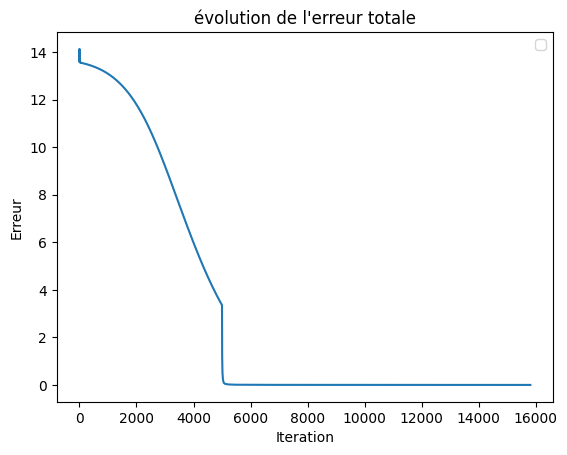

0.0009191131102852523


In [9]:
lines = plt.plot(losses)

plt.ylabel("Erreur")
plt.xlabel("Iteration")
plt.title(f"évolution de l'erreur totale")
plt.legend()
plt.show()
print(losses[-1])

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("../models/spee_ft/model_02/DS_Model_03.json", "r") as f:
    losses = json.load(f)

losses = np.array(losses)
# Colonnes : [total, ns, cont, inlet, wall, outlet, anchor, w_pde, lambda]
cols = {
    "total":   0,
    "ns":      1,
    "cont":    2,
    "inlet":   3,
    "wall":    4,
    "outlet":  5,
    "anchor":  6,
    "w_pde":   7,
    "lambda":  8,
}

epochs = np.arange(len(losses))

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Évolution des loss", fontsize=14)

# Total
axes[0, 0].semilogy(epochs, losses[:, cols["total"]])
axes[0, 0].set_title("Total")
axes[0, 0].set_xlabel("Epoch")

# NS + continuité
axes[0, 1].semilogy(epochs, losses[:, cols["ns"]],   label="NS momentum")
axes[0, 1].semilogy(epochs, losses[:, cols["cont"]], label="Continuité")
axes[0, 1].set_title("Résidus PDE")
axes[0, 1].legend()
axes[0, 1].set_xlabel("Epoch")

# BC
axes[1, 0].semilogy(epochs, losses[:, cols["inlet"]],  label="Inlet")
axes[1, 0].semilogy(epochs, losses[:, cols["wall"]],   label="Paroi")
axes[1, 0].semilogy(epochs, losses[:, cols["outlet"]], label="Outlet")
axes[1, 0].set_title("Conditions aux limites")
axes[1, 0].legend()
axes[1, 0].set_xlabel("Epoch")

# Ancrage
axes[1, 1].semilogy(epochs, losses[:, cols["anchor"]])
axes[1, 1].set_title("Ancrage élastique")
axes[1, 1].set_xlabel("Epoch")

# w_pde
axes[2, 0].plot(epochs, losses[:, cols["w_pde"]])
axes[2, 0].set_title("Curriculum w_pde")
axes[2, 0].set_xlabel("Epoch")
axes[2, 0].set_ylim(-0.05, 1.05)

# Lambda
axes[2, 1].semilogy(epochs, losses[:, cols["lambda"]])
axes[2, 1].set_title("λ ancrage")
axes[2, 1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("loss_evolution.png", dpi=150)
plt.show()

In [ ]:
x, y, uv = extract_ds_values(H5_FILE_T, 8)

# Vitesse magnitude max dans le domaine
speed = np.sqrt(uv[:, 0]**2 + uv[:, 1]**2)
V_max_data = speed.max()
print(f"V_max données : {V_max_data:.4f}")

# Vitesse max à l'inlet spécifiquement
inlet_mask = y < 0.01  # points proches de y=0
V_max_inlet = np.abs(uv[inlet_mask, 1]).max()  # composante v à l'entrée
print(f"V_max inlet   : {V_max_inlet:.4f}")

In [ ]:
outlet_points = torch.column_stack((
    torch.linspace(14.5 / 20, 17.85 / 20, 150),
    torch.zeros(150)
)).double().detach()

with torch.no_grad():
    p_pred = model(outlet_points)[:, 2]
    print(f"p outlet prédit  : {p_pred.mean():.4f} ± {p_pred.std():.4f}")
    print(f"P_fact imposé    : {0.521}")
    # Si écart > 0.1 → P_fact mal calibré

In [ ]:
with open("../models/spee_ft/model_02/DS_Model_03.json", "r") as f:
    losses = json.load(f)

losses = np.array(losses)

plt.plot(losses[:, 4])

plt.xlabel("Itération")
plt.ylabel("Erreur")
plt.title("Évolution de l'erreur")
plt.show()